In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('Dimuon_DoubleMu.csv')

In [3]:
data=data.sample(frac=1)
data.drop(['Run','Event','type1'],axis=1,inplace=True)
#data= data.set_index('Event')
data

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
12883,7.4977,1.0036,4.8510,-5.6272,4.9537,-0.9743,1.3668,-1,G,6.1865,-0.4305,-4.2428,4.4804,4.2646,0.9167,-1.6719,1,13.6104
43516,9.2037,-7.4932,-2.9068,-4.4832,8.0373,-0.5323,-2.7715,-1,G,7.8523,7.0636,1.0264,3.2710,7.1378,0.4436,0.1443,1,16.9032
21909,42.7097,0.3470,10.6108,-41.3690,10.6165,-2.0693,1.5381,1,G,76.9361,-27.4315,-10.5300,-71.1041,29.3831,-1.6171,-2.7751,-1,30.5180
54152,5.1683,-1.5401,-3.7219,3.2366,4.0279,0.7354,-1.9631,-1,G,11.5727,2.0450,8.9325,7.0672,9.1636,0.7100,1.3457,1,12.1114
92717,5.6622,4.7208,2.6795,1.6075,5.4282,0.2920,0.5163,-1,G,5.8513,-2.9927,4.2627,2.6645,5.2083,0.4915,2.1829,1,7.9454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63350,8.5893,-5.0814,2.4335,-6.4824,5.6341,-0.9839,2.6950,1,G,4.6943,4.1381,-2.1021,-0.6948,4.6414,-0.1491,-0.4700,-1,11.1329
38977,16.1738,8.0282,-4.1400,-13.4160,9.0328,-1.1866,-0.4761,-1,G,11.6846,-5.3732,1.8225,-10.2141,5.6738,-1.3505,2.8146,1,14.3280
19136,13.5102,-4.7425,-3.8146,-12.0612,6.0862,-1.4354,-2.4642,1,G,5.5122,4.3727,3.3366,-0.3468,5.5003,-0.0630,0.6518,-1,14.4059
23139,14.3142,-6.2901,-12.0276,4.5448,13.5731,0.3289,-2.0526,1,G,10.2529,-3.8535,-9.5000,0.1118,10.2518,0.0109,-1.9561,-1,3.9407


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 12883 to 38032
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   E1      100000 non-null  float64
 1   px1     100000 non-null  float64
 2   py1     100000 non-null  float64
 3   pz1     100000 non-null  float64
 4   pt1     100000 non-null  float64
 5   eta1    100000 non-null  float64
 6   phi1    100000 non-null  float64
 7   Q1      100000 non-null  int64  
 8   type2   100000 non-null  object 
 9   E2      100000 non-null  float64
 10  px2     100000 non-null  float64
 11  py2     100000 non-null  float64
 12  pz2     100000 non-null  float64
 13  pt2     100000 non-null  float64
 14  eta2    100000 non-null  float64
 15  phi2    100000 non-null  float64
 16  Q2      100000 non-null  int64  
 17  M       100000 non-null  float64
dtypes: float64(15), int64(2), object(1)
memory usage: 14.5+ MB


In [5]:
data.isnull()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
12883,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
43516,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21909,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
54152,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
92717,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63350,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
38977,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19136,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
23139,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

<Axes: >

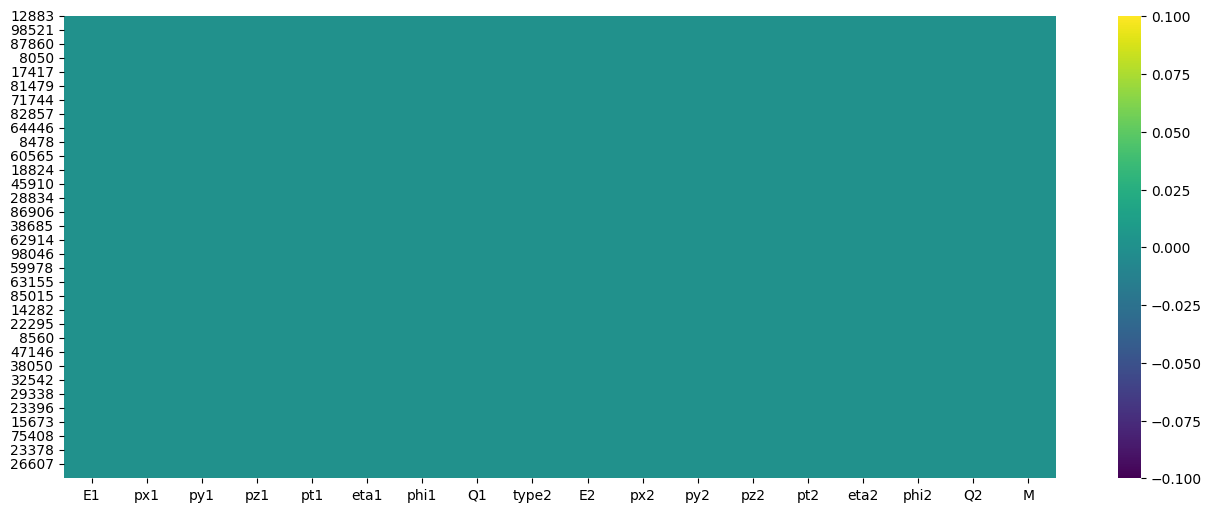

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

In [10]:
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
12883,7.4977,1.0036,4.8510,-5.6272,4.9537,-0.9743,1.3668,-1,G,6.1865,-0.4305,-4.2428,4.4804,4.2646,0.9167,-1.6719,1,13.6104
43516,9.2037,-7.4932,-2.9068,-4.4832,8.0373,-0.5323,-2.7715,-1,G,7.8523,7.0636,1.0264,3.2710,7.1378,0.4436,0.1443,1,16.9032
21909,42.7097,0.3470,10.6108,-41.3690,10.6165,-2.0693,1.5381,1,G,76.9361,-27.4315,-10.5300,-71.1041,29.3831,-1.6171,-2.7751,-1,30.5180
54152,5.1683,-1.5401,-3.7219,3.2366,4.0279,0.7354,-1.9631,-1,G,11.5727,2.0450,8.9325,7.0672,9.1636,0.7100,1.3457,1,12.1114
92717,5.6622,4.7208,2.6795,1.6075,5.4282,0.2920,0.5163,-1,G,5.8513,-2.9927,4.2627,2.6645,5.2083,0.4915,2.1829,1,7.9454


In [11]:
type2=pd.get_dummies(data['type2'],drop_first=True,dtype=float)
type2

,T
12883,0.0
43516,0.0
21909,0.0
54152,0.0
92717,0.0
...,...
63350,0.0
38977,0.0
19136,0.0
23139,0.0


In [12]:
data=pd.concat([data,type2],axis=1)
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,T
12883,7.4977,1.0036,4.8510,-5.6272,4.9537,-0.9743,1.3668,-1,G,6.1865,-0.4305,-4.2428,4.4804,4.2646,0.9167,-1.6719,1,13.6104,0.0
43516,9.2037,-7.4932,-2.9068,-4.4832,8.0373,-0.5323,-2.7715,-1,G,7.8523,7.0636,1.0264,3.2710,7.1378,0.4436,0.1443,1,16.9032,0.0
21909,42.7097,0.3470,10.6108,-41.3690,10.6165,-2.0693,1.5381,1,G,76.9361,-27.4315,-10.5300,-71.1041,29.3831,-1.6171,-2.7751,-1,30.5180,0.0
54152,5.1683,-1.5401,-3.7219,3.2366,4.0279,0.7354,-1.9631,-1,G,11.5727,2.0450,8.9325,7.0672,9.1636,0.7100,1.3457,1,12.1114,0.0
92717,5.6622,4.7208,2.6795,1.6075,5.4282,0.2920,0.5163,-1,G,5.8513,-2.9927,4.2627,2.6645,5.2083,0.4915,2.1829,1,7.9454,0.0


In [13]:
data.drop(['type2'],axis=1,inplace=True)
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,T
12883,7.4977,1.0036,4.8510,-5.6272,4.9537,-0.9743,1.3668,-1,6.1865,-0.4305,-4.2428,4.4804,4.2646,0.9167,-1.6719,1,13.6104,0.0
43516,9.2037,-7.4932,-2.9068,-4.4832,8.0373,-0.5323,-2.7715,-1,7.8523,7.0636,1.0264,3.2710,7.1378,0.4436,0.1443,1,16.9032,0.0
21909,42.7097,0.3470,10.6108,-41.3690,10.6165,-2.0693,1.5381,1,76.9361,-27.4315,-10.5300,-71.1041,29.3831,-1.6171,-2.7751,-1,30.5180,0.0
54152,5.1683,-1.5401,-3.7219,3.2366,4.0279,0.7354,-1.9631,-1,11.5727,2.0450,8.9325,7.0672,9.1636,0.7100,1.3457,1,12.1114,0.0
92717,5.6622,4.7208,2.6795,1.6075,5.4282,0.2920,0.5163,-1,5.8513,-2.9927,4.2627,2.6645,5.2083,0.4915,2.1829,1,7.9454,0.0


In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 12883 to 38032
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   E1      100000 non-null  float64
 1   px1     100000 non-null  float64
 2   py1     100000 non-null  float64
 3   pz1     100000 non-null  float64
 4   pt1     100000 non-null  float64
 5   eta1    100000 non-null  float64
 6   phi1    100000 non-null  float64
 7   Q1      100000 non-null  int64  
 8   E2      100000 non-null  float64
 9   px2     100000 non-null  float64
 10  py2     100000 non-null  float64
 11  pz2     100000 non-null  float64
 12  pt2     100000 non-null  float64
 13  eta2    100000 non-null  float64
 14  phi2    100000 non-null  float64
 15  Q2      100000 non-null  int64  
 16  M       100000 non-null  float64
 17  T       100000 non-null  float64
dtypes: float64(16), int64(2)
memory usage: 14.5 MB


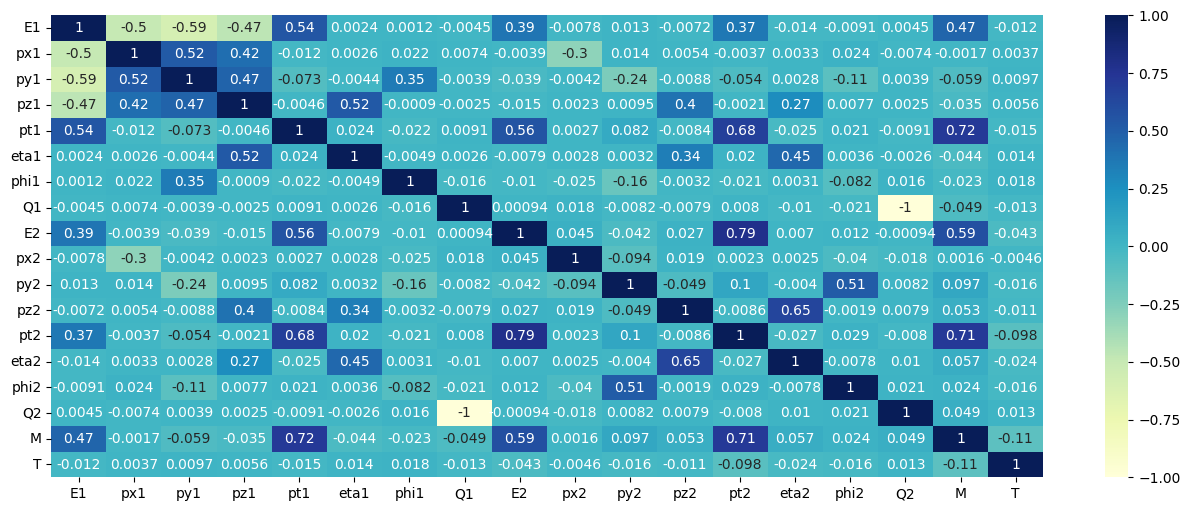

In [15]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [35]:
corrM[corrM['E2']>0.1][['E2']]

,E2
E1,0.387911
pt1,0.559408
E2,1.000000
pt2,0.786694
M,0.587391


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x=data.drop(['E2'],axis=1)
x=data[['E1','pt1','pt2','M']]

x.head()

,E1,pt1,pt2,M
12883,7.4977,4.9537,4.2646,13.6104
43516,9.2037,8.0373,7.1378,16.9032
21909,42.7097,10.6165,29.3831,30.5180
54152,5.1683,4.0279,9.1636,12.1114
92717,5.6622,5.4282,5.2083,7.9454


In [19]:
y=data['E2']
y

12883     6.1865
43516     7.8523
21909    76.9361
54152    11.5727
92717     5.8513
          ...   
63350     4.6943
38977    11.6846
19136     5.5122
23139    10.2529
38032     7.7674
Name: E2, Length: 100000, dtype: float64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.005, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model=LinearRegression()

In [23]:
model.fit(X_train,y_train)

LinearRegression()

In [24]:
pred=model.predict(X_test)
pred

array([12.46160659,  6.53313478, 24.37290008,  6.94102952, 72.92182692,
       13.52825861, 21.08991978,  9.50655055, 10.08204395, 13.80621792,
        6.58166826,  6.53630217, 12.83126605,  7.22401247, 20.37342322,
        7.8222667 ,  5.90809241,  5.74203831, 14.68726194,  6.42921206,
       10.85087697,  8.83264749,  8.86125983,  9.63513199, 15.55673904,
       25.82425644,  8.19448171, 23.35654134, 12.73948213,  7.68579343,
        9.2398443 , 28.80779279, 10.06677561, 58.72632785, 15.01673232,
        5.98126598, 18.32831068, 11.26771409, 12.70979046, 12.1498107 ,
        7.83260014, 10.84542522,  7.09447319,  7.03934682,  5.1006193 ,
        6.44596017,  6.9081327 , 13.40499051,  5.21246004,  7.24269104,
       23.05506112, 17.9012989 , 16.49962021,  9.35076481, 18.81904111,
       15.3563437 , 15.38871848,  6.5103718 , 25.11606412, 37.2089692 ,
       12.34408625,  6.93020253, 24.00716506, 11.8948828 , 19.83509025,
       15.93797329,  7.95018102,  7.5003568 ,  8.04177277, 14.87

In [25]:
y_test

88037     8.7898
1197      4.4797
84461    18.9168
91159     5.6743
19318    55.9076
          ...   
861       7.0719
39647    35.5476
53797    10.4062
35801     4.8288
54733     4.9758
Name: E2, Length: 500, dtype: float64

In [26]:
X_test

,E1,pt1,pt2,M
88037,18.0084,17.1782,8.5432,3.0837
1197,11.6862,5.0792,4.0221,10.1957
84461,11.8488,11.5671,17.8316,2.0398
91159,6.7152,6.3574,4.5413,12.0922
19318,12.9230,12.6786,54.9582,3.5738
...,...,...,...,...
861,10.7207,5.1937,5.0295,17.1841
39647,16.5634,8.1893,22.9566,9.3041
53797,5.8109,4.0384,4.4816,8.8216
35801,9.9264,3.6131,1.3023,2.1984


In [27]:
model.score(X_test, y_test)

0.7507048883817762

In [28]:
pred

array([12.46160659,  6.53313478, 24.37290008,  6.94102952, 72.92182692,
       13.52825861, 21.08991978,  9.50655055, 10.08204395, 13.80621792,
        6.58166826,  6.53630217, 12.83126605,  7.22401247, 20.37342322,
        7.8222667 ,  5.90809241,  5.74203831, 14.68726194,  6.42921206,
       10.85087697,  8.83264749,  8.86125983,  9.63513199, 15.55673904,
       25.82425644,  8.19448171, 23.35654134, 12.73948213,  7.68579343,
        9.2398443 , 28.80779279, 10.06677561, 58.72632785, 15.01673232,
        5.98126598, 18.32831068, 11.26771409, 12.70979046, 12.1498107 ,
        7.83260014, 10.84542522,  7.09447319,  7.03934682,  5.1006193 ,
        6.44596017,  6.9081327 , 13.40499051,  5.21246004,  7.24269104,
       23.05506112, 17.9012989 , 16.49962021,  9.35076481, 18.81904111,
       15.3563437 , 15.38871848,  6.5103718 , 25.11606412, 37.2089692 ,
       12.34408625,  6.93020253, 24.00716506, 11.8948828 , 19.83509025,
       15.93797329,  7.95018102,  7.5003568 ,  8.04177277, 14.87

In [29]:
y_test

88037     8.7898
1197      4.4797
84461    18.9168
91159     5.6743
19318    55.9076
          ...   
861       7.0719
39647    35.5476
53797    10.4062
35801     4.8288
54733     4.9758
Name: E2, Length: 500, dtype: float64

In [30]:
indexes = X_test.index.values
len(indexes)

500

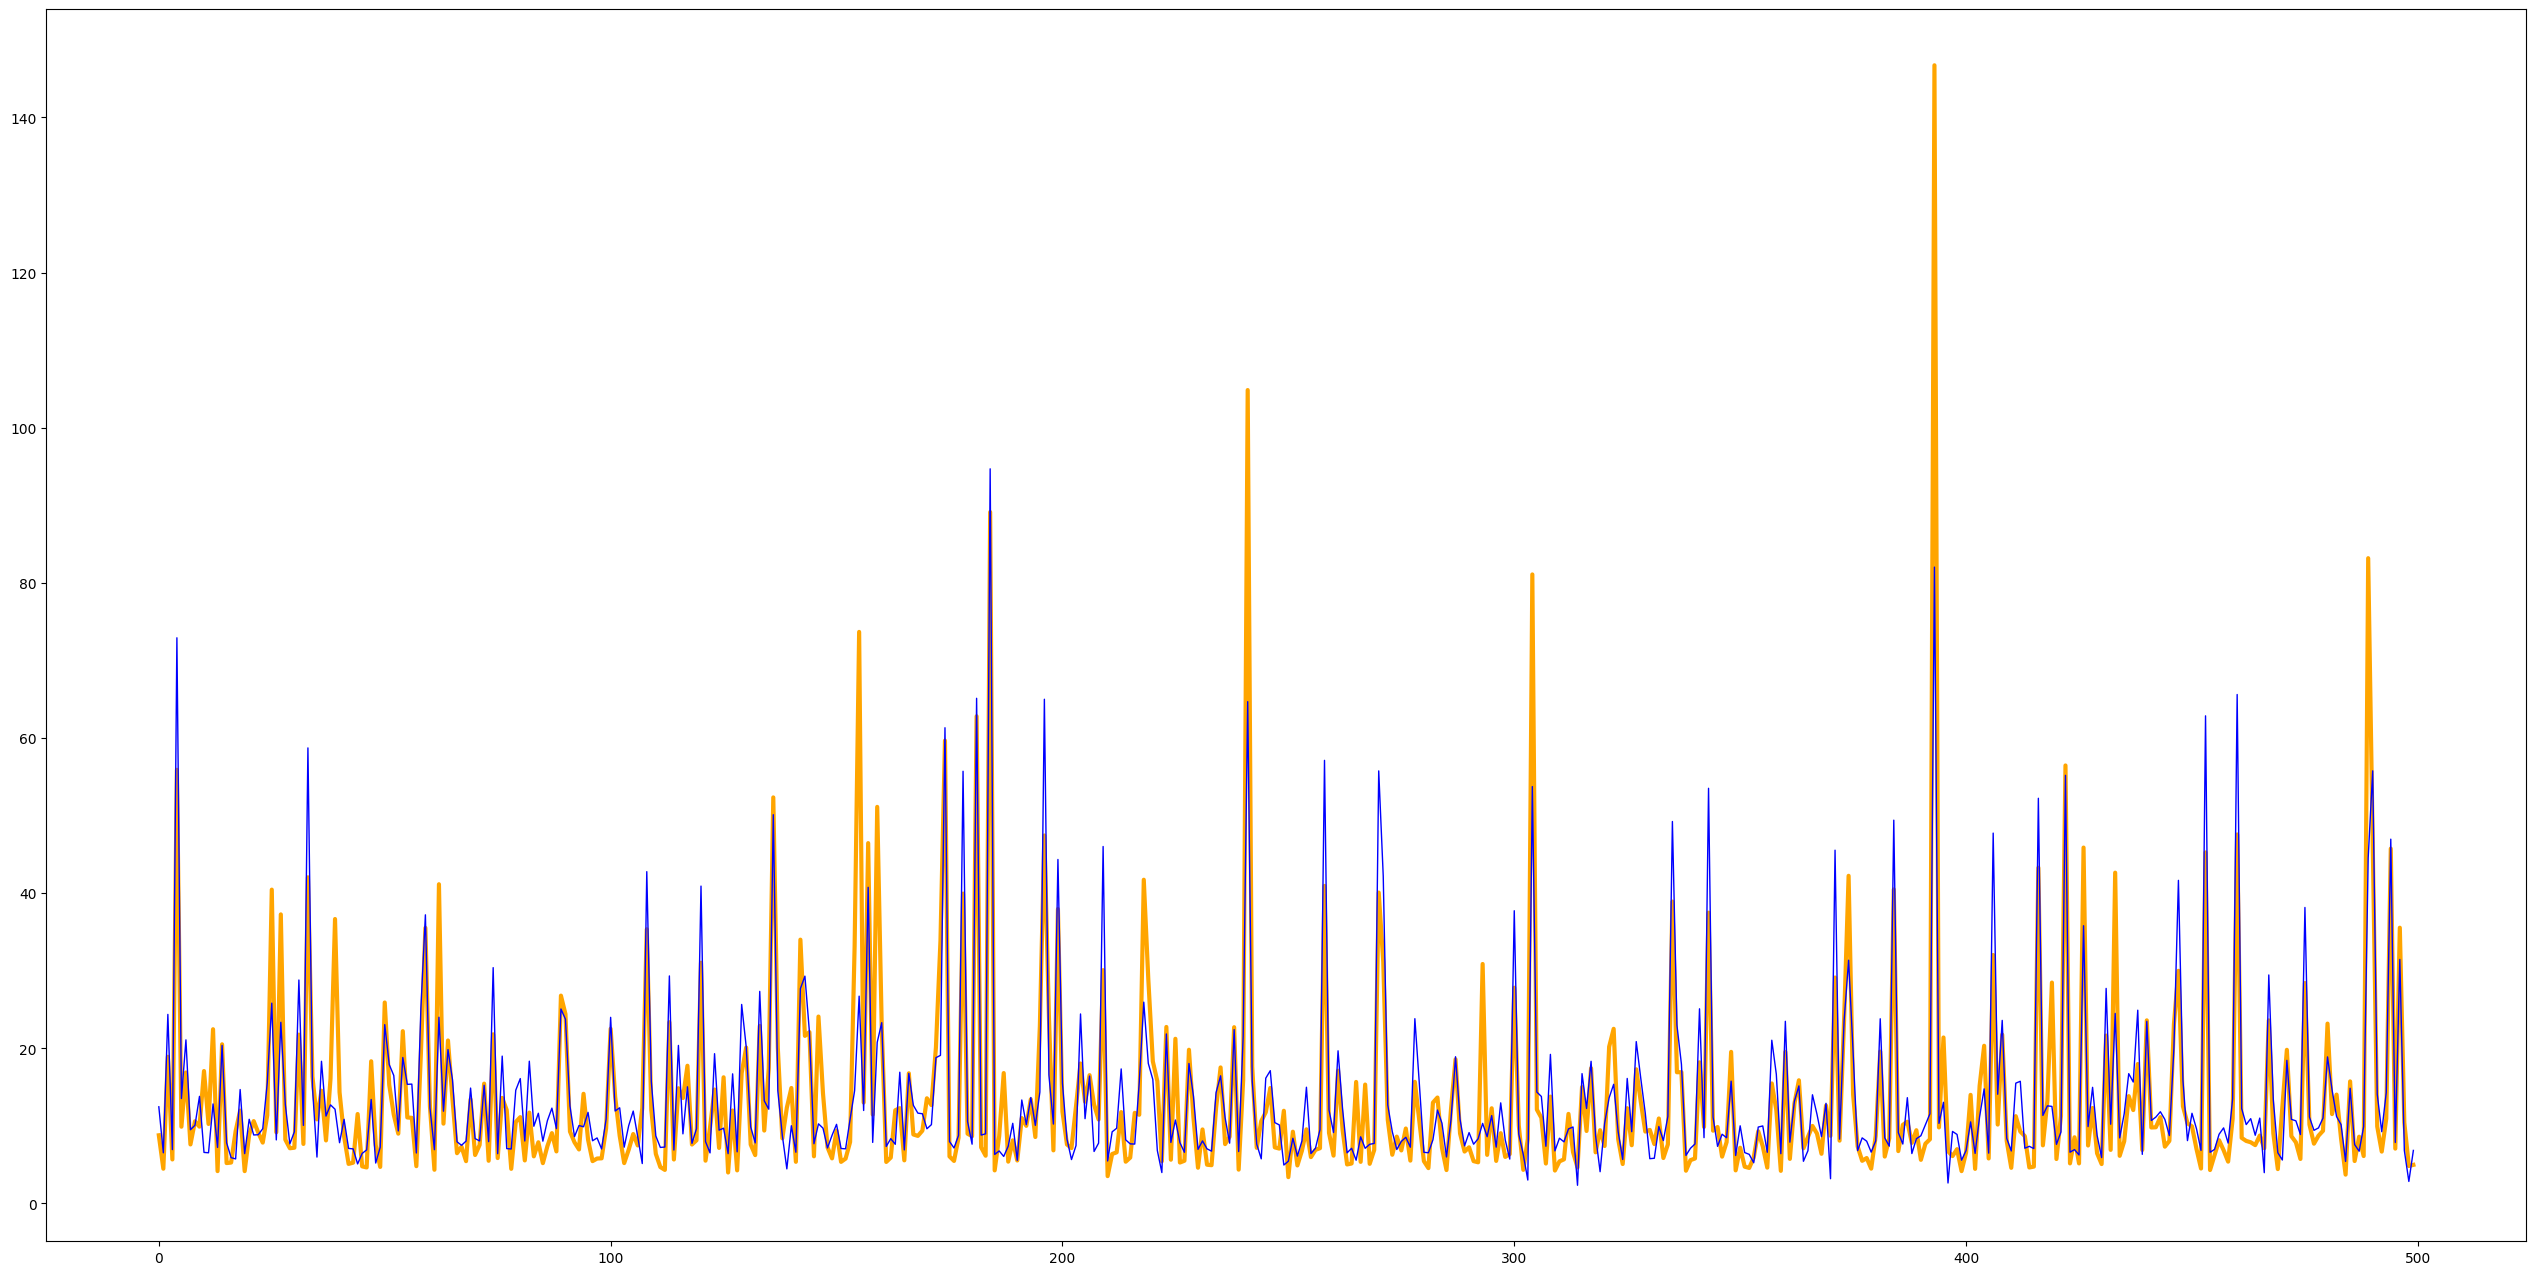

In [31]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes)),y_test, color="orange", linewidth=3)
plt.plot(range(0,len(indexes)),pred, color="blue", linewidth=1)
plt.show()